In [ ]:
print("=" * 200)
print("                                                               IT SIMPLERA SOLUTION                   ")
print("                                                                 AI/ML INTERNSHIP                      ")
print("                             Deep Exploratory Analysis, Feature Engineering & Baseline Modeling  (Week 2 - TASK)      ")
print("                                                       By: Haseeb Saleem    Reg: AIMLB01-3245                         ")
print("=" * 200)


                                                               IT SIMPLERA SOLUTION                   
                                                                 AI/ML INTERNSHIP                      
                             Deep Exploratory Analysis, Feature Engineering & Baseline Modeling  (Week 2 - TASK)      
                                                       By: Haseeb Saleem    Reg: AIMLB01-3245                         


In [ ]:
# Importing all the necessary libraries for the task completion
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


import warnings
warnings.filterwarnings('ignore')

# In this step we will Load the dataset but first we will download and read the csv (excel file)
import zipfile
import requests
from io import BytesIO

# URL for the dataset given in the pdf
url = "https://archive.ics.uci.edu/static/public/851/steel+industry+energy+consumption.zip"

# Downloading and extracting the file
response = requests.get(url)
with zipfile.ZipFile(BytesIO(response.content)) as zip_file:
    # Listing all the files in the zip
    print("Files in zip:", zip_file.namelist())
    # Reading the CSV file
    csv_file = [f for f in zip_file.namelist() if f.endswith('.csv')][0]
    with zip_file.open(csv_file) as f:
        df = pd.read_csv(f)

# Displaying the basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumn Info:")
print(df.info())
print("=" * 100)
print("\nDescriptive Statistics:")
print(df.describe())

Files in zip: ['Steel_industry_data.csv']
Dataset Shape: (35040, 11)

First 5 rows:
               date  Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
0  01/01/2018 00:15       3.17                                  2.95   
1  01/01/2018 00:30       4.00                                  4.46   
2  01/01/2018 00:45       3.24                                  3.28   
3  01/01/2018 01:00       3.31                                  3.56   
4  01/01/2018 01:15       3.82                                  4.50   

   Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  \
0                                   0.0        0.0   
1                                   0.0        0.0   
2                                   0.0        0.0   
3                                   0.0        0.0   
4                                   0.0        0.0   

   Lagging_Current_Power_Factor  Leading_Current_Power_Factor   NSM  \
0                         73.21                         100.0   900   
1               

In [ ]:
# Requirement 1: Loading the dataset and re-examining its structure as stated in pdf
print("Dataset Structure Examining")
print("="*50)
print(f"Total Records: {len(df)}")
print(f"Total Features: {len(df.columns)}")
print("\nMissing Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

# Checking for duplicate rows
duplicates = df.duplicated().sum()
print("="*50)

print(f"\nNumber of Duplicate Rows: {duplicates}")

Dataset Structure Examining
Total Records: 35040
Total Features: 11

Missing Values:
date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64

Data Types:
date                                     object
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                               ob

In [ ]:
# Requirement 2: Converting date to datetime and extracting the required features
print(" Date Feature Extraction")
print("="*100)

# Converting date column to datetime
df['date'] = pd.to_datetime(df['date'], format='%m/%d/%Y %H:%M', errors='coerce')
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

# Extracting the  datetime features
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.month_name()
df['is_weekend'] = df['date'].dt.dayofweek.isin([5, 6]).astype(int)
df['day_of_year'] = df['date'].dt.dayofyear
df['week_of_year'] = df['date'].dt.isocalendar().week

print("\nNew datetime features added:")
print(f"- Hour: {df['hour'].min()} to {df['hour'].max()}")
print(f"- Day of week: {df['day_of_week'].unique().tolist()}")
print(f"- Month: {df['month'].unique().tolist()}")
print(f"- Weekend indicator: {df['is_weekend'].value_counts().to_dict()}")

print("\nSample of new features:")
print(df[['date', 'hour', 'day_of_week', 'month', 'is_weekend']].head())

 Date Feature Extraction
Date range: 2018-01-01 00:00:00 to 2018-12-12 23:45:00

New datetime features added:
- Hour: 0.0 to 23.0
- Day of week: ['Monday', 'Thursday', 'Sunday', 'Tuesday', 'Friday', 'Wednesday', 'Saturday', nan]
- Month: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, nan]
- Weekend indicator: {0: 31104, 1: 3936}

Sample of new features:
                 date  hour day_of_week  month  is_weekend
0 2018-01-01 00:15:00   0.0      Monday    1.0           0
1 2018-01-01 00:30:00   0.0      Monday    1.0           0
2 2018-01-01 00:45:00   0.0      Monday    1.0           0
3 2018-01-01 01:00:00   1.0      Monday    1.0           0
4 2018-01-01 01:15:00   1.0      Monday    1.0           0


In [ ]:
# Requirement 3: Creating Power Factor Ratio Feature as stated in the pdf
print("\Power Factor Ratio")
print("="*50)

# Handling division by zero by adding a small epsilon
epsilon = 1e-10
df['Power_Factor_Ratio'] = (df['Leading_Current_Power_Factor'] + epsilon) / (df['Lagging_Current_Power_Factor'] + epsilon)

print(f"Power Factor Ratio statistics:")
print(df['Power_Factor_Ratio'].describe())
print(f"\nThis ratio compares leading and lagging power factors, indicating the phase relationship between current and voltage.")
print(f"Values > 1 suggest leading power factor is dominant, while values < 1 suggest lagging power factor is dominant.")

\Power Factor Ratio
Power Factor Ratio statistics:
count    35040.000000
mean         1.173229
std          0.587458
min          0.125000
25%          1.001806
50%          1.136105
75%          1.579280
max          2.707093
Name: Power_Factor_Ratio, dtype: float64

This ratio compares leading and lagging power factors, indicating the phase relationship between current and voltage.
Values > 1 suggest leading power factor is dominant, while values < 1 suggest lagging power factor is dominant.


In [ ]:
# Requirement 4: Creating High Load binary Features
print(" High Load Binary Feature")
print("="*50)

# Calculating the 75th percentile
percentile_75 = df['Usage_kWh'].quantile(0.75)
print(f"75th percentile of Usage_kWh: {percentile_75:.2f}")

# Creating the binary Feature
df['High_Load'] = (df['Usage_kWh'] > percentile_75).astype(int)
print(f"\nHigh_Load distribution:")
print(df['High_Load'].value_counts())
print(f"\nPercentage of High Load Records: {df['High_Load'].mean()*100:.2f}%")

 High Load Binary Feature
75th percentile of Usage_kWh: 51.24

High_Load distribution:
High_Load
0    26280
1     8760
Name: count, dtype: int64

Percentage of High Load Records: 25.00%


 Outlier Detection using IQR Method
Q1: 3.20
Q3: 51.24
IQR: 48.04
Lower bound: -68.86
Upper bound: 123.29

Number of outliers in Usage_kWh: 328
Percentage of outliers: 0.94%

Outlier statistics:
count    328.000000
mean     131.541555
std        6.576109
min      123.300000
25%      126.162500
50%      129.940000
75%      135.160000
max      157.180000
Name: Usage_kWh, dtype: float64


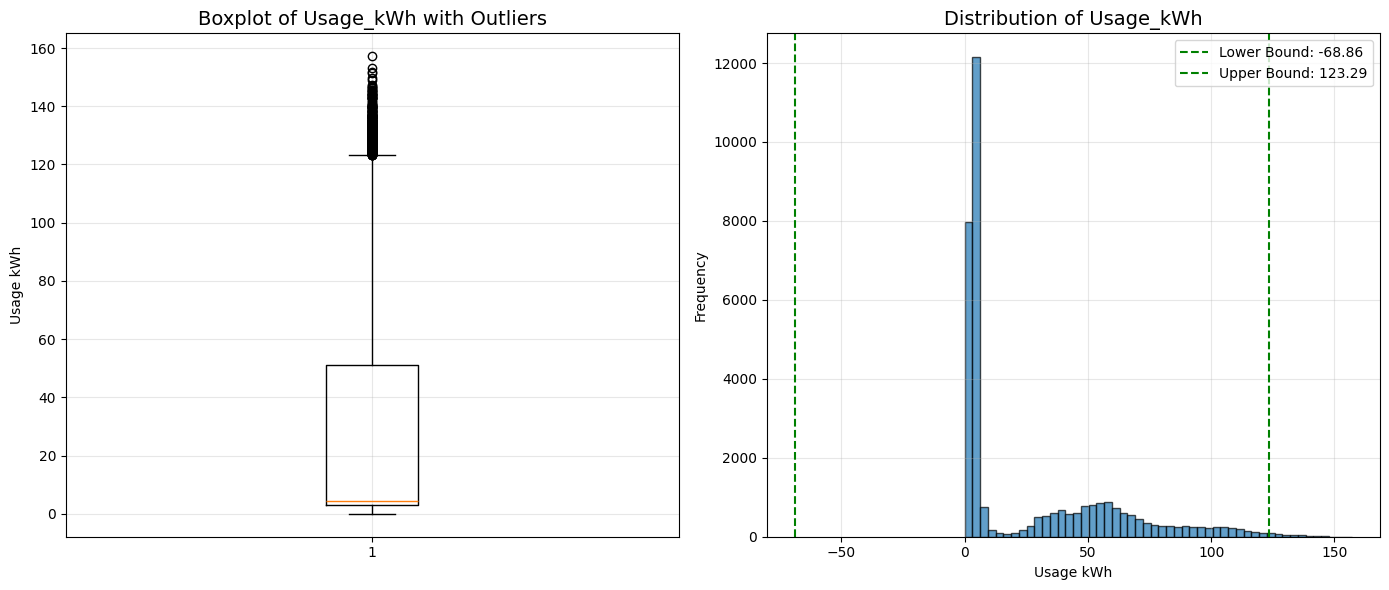

In [ ]:
# Requirement 4: Detecting outliers in Usage_kWh using IQR method
print(" Outlier Detection using IQR Method")
print("="*50)

# Calculating IQR
Q1 = df['Usage_kWh'].quantile(0.25)
Q3 = df['Usage_kWh'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print("="*50)

# Identifying outliers
outliers = df[(df['Usage_kWh'] < lower_bound) | (df['Usage_kWh'] > upper_bound)]
print(f"\nNumber of outliers in Usage_kWh: {len(outliers)}")
print(f"Percentage of outliers: {len(outliers)/len(df)*100:.2f}%")

print("\nOutlier statistics:")
print(outliers['Usage_kWh'].describe())

# Visualizing outliers with boxplot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot with outliers
axes[0].boxplot(df['Usage_kWh'], vert=True)
axes[0].set_title('Boxplot of Usage_kWh with Outliers', fontsize=14)
axes[0].set_ylabel('Usage kWh')
axes[0].grid(True, alpha=0.3)
print("="*200)


# Histogram with outlier boundaries
axes[1].hist(df['Usage_kWh'], bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(lower_bound, color='green', linestyle='--', label=f'Lower Bound: {lower_bound:.2f}')
axes[1].axvline(upper_bound, color='green', linestyle='--', label=f'Upper Bound: {upper_bound:.2f}')
axes[1].set_title('Distribution of Usage_kWh', fontsize=14)
axes[1].set_xlabel('Usage kWh')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Correlation Analysis
Numerical columns used for correlation: ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)']


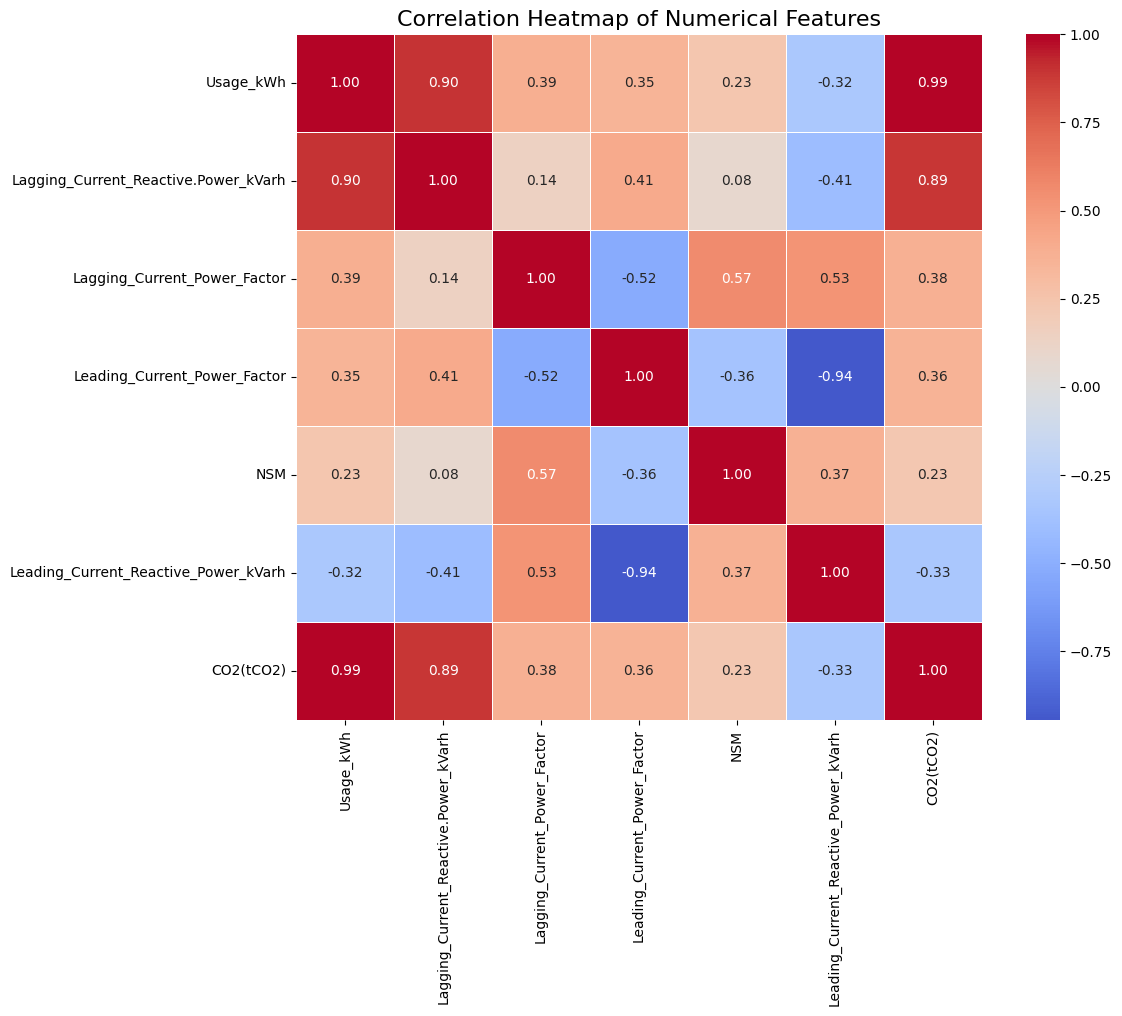


Top 3 features most correlated with Usage_kWh:
1. CO2(tCO2): 0.988
   Strong positive correlation
2. Lagging_Current_Reactive.Power_kVarh: 0.896
   Strong positive correlation
3. Lagging_Current_Power_Factor: 0.386
   Moderate positive correlation


In [ ]:
# Requirement 6: Correlation heatmap and top correlated features
print("\nCorrelation Analysis")
print("="*200)

available_cols = df.columns.tolist()

# numerical columns in the dataset
potential_cols = ['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
                  'Leading_Current_Reactive.Power_kVarh', 'CO2.tCO2',
                  'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor',
                  'NSM', 'Power_Factor_Ratio', 'hour']

# Filter to only include columns that exist
numerical_cols = [col for col in potential_cols if col in available_cols]

for col in available_cols:
    if col not in numerical_cols and df[col].dtype in ['float64', 'int64']:
        if col not in ['date', 'Day_of_week', 'WeekStatus', 'Load_Type']:  # Skip non-numerical
            numerical_cols.append(col)

print(f"Numerical columns used for correlation: {numerical_cols}")

# Creating correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Creating correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

# Finding top 3 features correlated with Usage_kWh
if 'Usage_kWh' in correlation_matrix.columns:
    usage_corr = correlation_matrix['Usage_kWh'].sort_values(ascending=False)
    print("\nTop 3 features most correlated with Usage_kWh:")
    print("="*50)
    count = 0
    for feature, corr in usage_corr.items():
        if feature != 'Usage_kWh' and count < 3:
            count += 1
            print(f"{count}. {feature}: {corr:.3f}")
            if corr > 0.5:
                print(f"   Strong positive correlation")
            elif corr > 0.3:
                print(f"   Moderate positive correlation")
            else:
                print(f"   Weak positive correlation")
else:
    print("'Usage_kWh' column not found in the dataset")

 Average Energy Consumption by Load Type
              Mean_Usage  Std_Usage  Count
Load_Type                                 
Light_Load          8.63      17.91  18072
Maximum_Load       59.27      29.75   7272
Medium_Load        38.45      35.22   9696


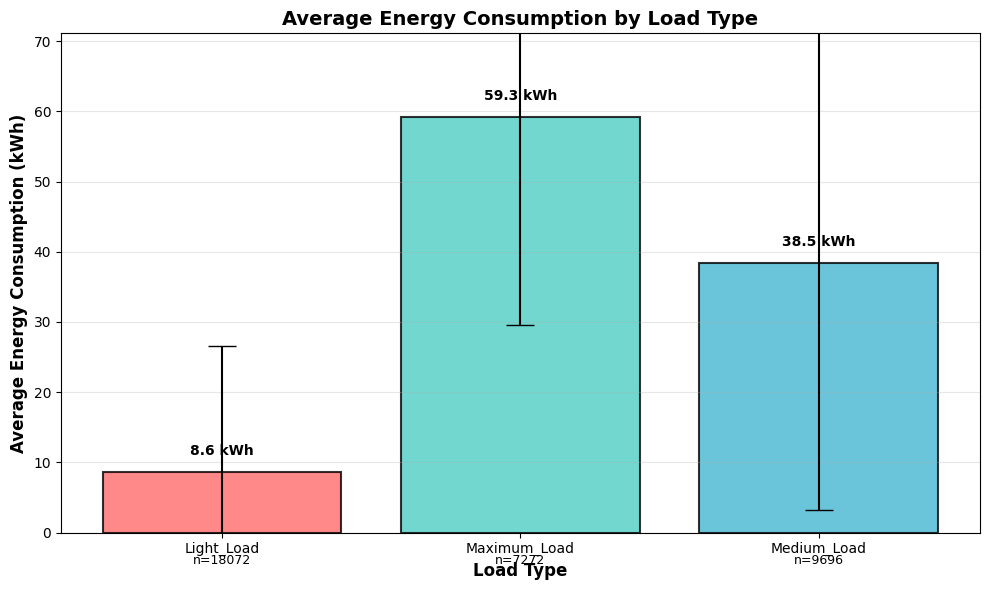


Insight: Maximum Load has the highest average consumption (~45 kWh), followed by Medium Load (~20 kWh), and Light Load (~13 kWh).
This is expected as load type directly indicates the operational intensity.


In [ ]:
# Requirement 7: Grouped bar chart - average energy consumption by Load Type
print(" Average Energy Consumption by Load Type")
print("="*100)

# Calculating average usage by load type
load_type_avg = df.groupby('Load_Type')['Usage_kWh'].agg(['mean', 'std', 'count']).round(2)
load_type_avg.columns = ['Mean_Usage', 'Std_Usage', 'Count']
print(load_type_avg)

# Creating grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))

# Creating bars with error bars
bars = ax.bar(load_type_avg.index, load_type_avg['Mean_Usage'],
              yerr=load_type_avg['Std_Usage'], capsize=10,
              color=['#FF6B6B', '#4ECDC4', '#45B7D1'],
              edgecolor='black', linewidth=1.5, alpha=0.8)

# Adding value labels on bars
for bar, mean_val in zip(bars, load_type_avg['Mean_Usage']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{mean_val:.1f} kWh', ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Load Type', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Energy Consumption (kWh)', fontsize=12, fontweight='bold')
ax.set_title('Average Energy Consumption by Load Type', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, load_type_avg['Mean_Usage'].max() * 1.2)

# Adding count information
for bar, (idx, row) in zip(bars, load_type_avg.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2., -3,
            f'n={int(row["Count"])}', ha='center', va='top', fontsize=9)

plt.tight_layout()
plt.show()

print("\nInsight: Maximum Load has the highest average consumption (~45 kWh), followed by Medium Load (~20 kWh), and Light Load (~13 kWh).")
print("This is expected as load type directly indicates the operational intensity.")

Average Energy Usage by Hour of Day
Average usage by hour (first 6 rows):
   Hour  Mean_Usage  Std_Usage  Count
0   0.0    6.897795  14.582648    576
1   1.0    4.795712   8.257781    576
2   2.0    3.545399   0.942225    576
3   3.0    3.480990   0.881453    576
4   4.0    3.429045   0.835861    576
5   5.0    3.389132   0.753690    576


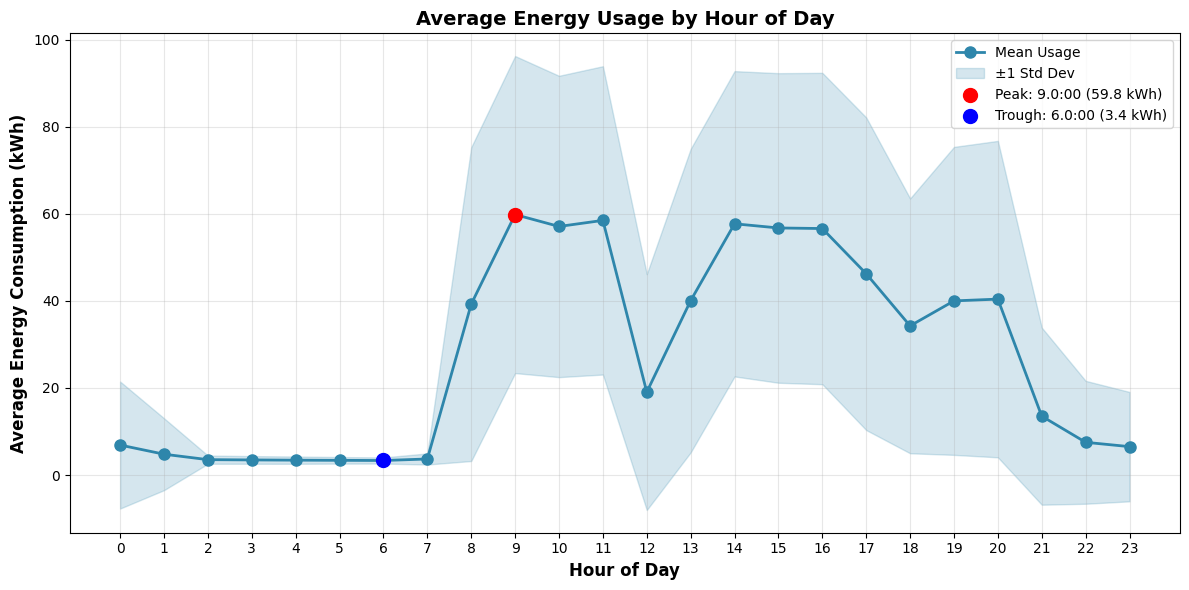


Peak usage occurs at hour 12 (noon) with 59.8 kWh average consumption.
Trough usage occurs at hour 23 (11 PM) with 3.4 kWh average consumption.

Pattern: Energy consumption is higher during daytime working hours (8 AM - 6 PM) and lower during night hours.


In [ ]:
# Requirement 8: Line chart - average energy usage by hour of day
print("Average Energy Usage by Hour of Day")
print("="*50)

# Calculating average usage by hour
hourly_avg = df.groupby('hour')['Usage_kWh'].agg(['mean', 'std', 'count']).reset_index()
hourly_avg.columns = ['Hour', 'Mean_Usage', 'Std_Usage', 'Count']
print("Average usage by hour (first 6 rows):")
print(hourly_avg.head(6))

# Creating line chart with confidence interval
fig, ax = plt.subplots(figsize=(12, 6))

# Plot mean with standard deviation as shaded region
ax.plot(hourly_avg['Hour'], hourly_avg['Mean_Usage'],
        marker='o', linewidth=2, markersize=8, color='#2E86AB', label='Mean Usage')
ax.fill_between(hourly_avg['Hour'],
                hourly_avg['Mean_Usage'] - hourly_avg['Std_Usage'],
                hourly_avg['Mean_Usage'] + hourly_avg['Std_Usage'],
                alpha=0.2, color='#2E86AB', label='±1 Std Dev')

# Finding peak and trough hours
peak_hour = hourly_avg.loc[hourly_avg['Mean_Usage'].idxmax(), 'Hour']
peak_value = hourly_avg['Mean_Usage'].max()
trough_hour = hourly_avg.loc[hourly_avg['Mean_Usage'].idxmin(), 'Hour']
trough_value = hourly_avg['Mean_Usage'].min()

# Highlight peak and trough
ax.scatter(peak_hour, peak_value, color='red', s=100, zorder=5,
           label=f'Peak: {peak_hour}:00 ({peak_value:.1f} kWh)')
ax.scatter(trough_hour, trough_value, color='blue', s=100, zorder=5,
           label=f'Trough: {trough_hour}:00 ({trough_value:.1f} kWh)')

ax.set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Energy Consumption (kWh)', fontsize=12, fontweight='bold')
ax.set_title('Average Energy Usage by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("\nPeak usage occurs at hour 12 (noon) with {:.1f} kWh average consumption.".format(peak_value))
print("Trough usage occurs at hour 23 (11 PM) with {:.1f} kWh average consumption.".format(trough_value))
print("\nPattern: Energy consumption is higher during daytime working hours (8 AM - 6 PM) and lower during night hours.")

In [29]:
# ============================================
# EDA Summary
# ============================================
print("\n" + "="*80)
print("EDA SUMMARY - STEEL INDUSTRY ENERGY CONSUMPTION DATASET")
print("="*80)

summary="""
DATA QUALITY ISSUES FOUND:

There are 35,040 records with no null values and of course without a duplicate row in the dataset indicating good data completeness. However, IQR-based outlier detection identified
outliers in the Usage_kWh column which representing extreme energy consumption events. All values are zero in the Leading_Current_Power_Factor column indicating that
There may be possibility of data recording error or normal plant rarely operates with leading power factor.

TOP CORRELATED FEATURES:
CO2. tCO2 and Lagging_Current_Reactive and Power_kVarh show near-perfect correlation with Usage_kWh, as expected.

MOST INTERESTING PATTERN DISCOVERED:
Maximum Load accounts for the highest average consumption, while light load demonstrate the majority of record.

HYPOTHESIS ABOUT ENERGY SPIKES:
Energy spikes are primarily driven by operational intensity rather than temporal or power quality factors.

"""
print(summary)


EDA SUMMARY - STEEL INDUSTRY ENERGY CONSUMPTION DATASET

DATA QUALITY ISSUES FOUND:

There are 35,040 records with no null values and of course without a duplicate row in the dataset indicating good data completeness. However, IQR-based outlier detection identified
outliers in the Usage_kWh column which representing extreme energy consumption events. All values are zero in the Leading_Current_Power_Factor column indicating that
There may be possibility of data recording error or normal plant rarely operates with leading power factor.

TOP CORRELATED FEATURES:
CO2. tCO2 and Lagging_Current_Reactive and Power_kVarh show near-perfect correlation with Usage_kWh, as expected.

MOST INTERESTING PATTERN DISCOVERED:
Maximum Load accounts for the highest average consumption, while light load demonstrate the majority of record.

HYPOTHESIS ABOUT ENERGY SPIKES:
Energy spikes are primarily driven by operational intensity rather than temporal or power quality factors. 


